# 03 - Analisis exploratorio


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
ROOT = Path("..").resolve()
df = pd.read_csv(ROOT / "data" / "processed" / "streaming_users_processed.csv")
df.head()


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estandar,805.8,Brasil,Crimen,2025-03-04,5
1,10001,37,Estandar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Basico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Basico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Basico,477.8,Peru,Thriller,2020-09-30,1


In [2]:
df[["age", "monthly_watch_time_mins", "customer_support_tickets"]].describe().round(2)


,age,monthly_watch_time_mins,customer_support_tickets
count,8000.00,8000.00,8000.00
mean,33.71,809.03,0.84
std,11.46,506.87,0.97
min,13.00,0.00,0.00
25%,26.00,498.98,0.00
50%,33.00,772.45,1.00
75%,41.00,1063.03,1.00
max,80.00,3628.40,5.00


## 1. Univariado: distribucion del tiempo mensual



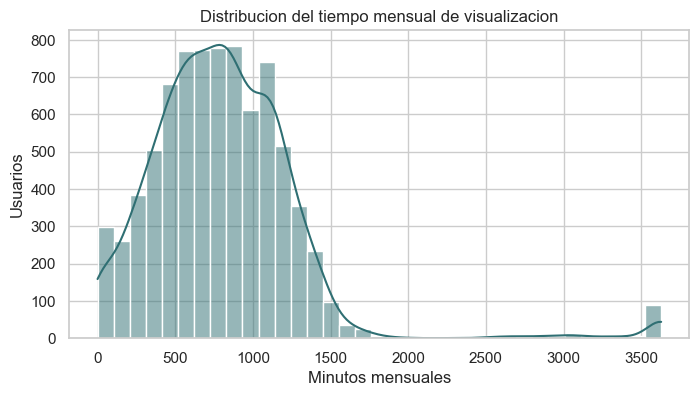

In [3]:
plt.figure(figsize=(8,4))
sns.histplot(df["monthly_watch_time_mins"], bins=35, kde=True, color="#2f6f73")
plt.title("Distribucion del tiempo mensual de visualizacion")
plt.xlabel("Minutos mensuales")
plt.ylabel("Usuarios")
plt.show()


Interpretacion: la mayoria de usuarios se concentra en consumos medios, pero aparece una cola de usuarios intensivos. Por eso no conviene mirar solo el promedio; la mediana ayuda a leer mejor una distribucion con extremos.


## 2. Univariado: usuarios por plan

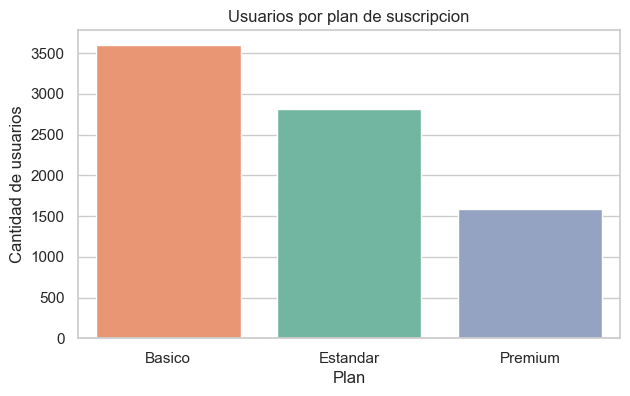

In [4]:
plt.figure(figsize=(7,4))
orden = df["subscription_plan"].value_counts().index
sns.countplot(data=df, x="subscription_plan", order=orden, hue="subscription_plan", palette="Set2", legend=False)
plt.title("Usuarios por plan de suscripcion")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")
plt.show()


Interpretacion: este grafico me dice cuanto pesa cada plan dentro del dataset. Si un plan tiene muchos mas usuarios que otro, despues hay que tener cuidado al comparar segmentos.


## 3. Bivariado: edad y consumo mensual


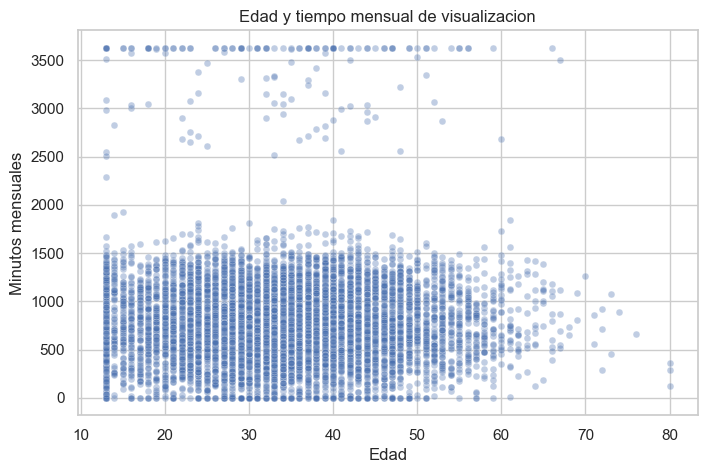

Correlacion edad-consumo: 0.007


In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="monthly_watch_time_mins", alpha=0.35, s=24)
plt.title("Edad y tiempo mensual de visualizacion")
plt.xlabel("Edad")
plt.ylabel("Minutos mensuales")
plt.show()
print("Correlacion edad-consumo:", round(df["age"].corr(df["monthly_watch_time_mins"]), 3))


Interpretacion: la nube de puntos queda bastante dispersa. La edad suma contexto, pero no explica sola el consumo; por eso despues miro otras variables como plan o genero favorito.


## 4. Bivariado: consumo mensual por plan

Pregunta que miro: el consumo cambia segun el plan de suscripcion?


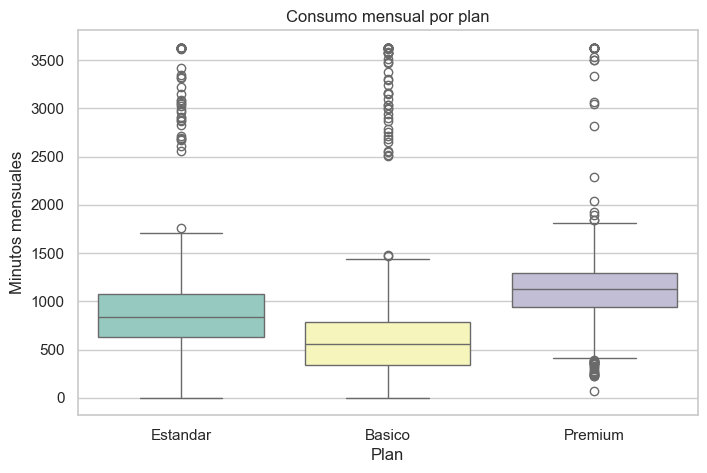

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="subscription_plan", y="monthly_watch_time_mins", hue="subscription_plan", palette="Set3", legend=False)
plt.title("Consumo mensual por plan")
plt.xlabel("Plan")
plt.ylabel("Minutos mensuales")
plt.show()


Interpretacion: el boxplot compara medianas y dispersion entre planes. Si un plan tiene una mediana mas alta, puede marcar usuarios mas intensivos dentro de ese grupo.


## 5. Multivariado: edad, consumo y genero favorito


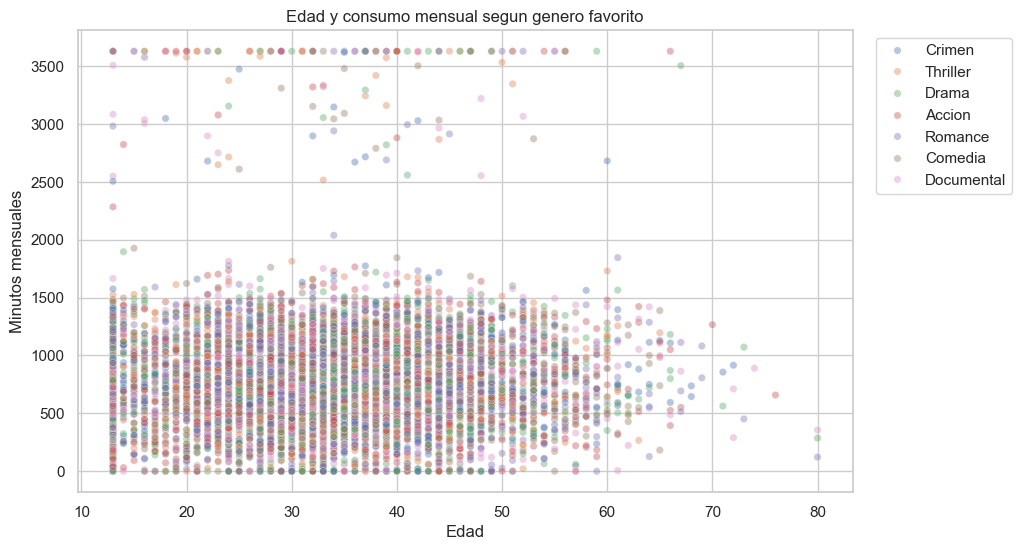

In [7]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="age", y="monthly_watch_time_mins", hue="favorite_genre", alpha=0.4, s=28)
plt.title("Edad y consumo mensual segun genero favorito")
plt.xlabel("Edad")
plt.ylabel("Minutos mensuales")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


In [8]:
resumen_genero = (
    df.groupby("favorite_genre")
      .agg(
          usuarios=("user_id", "count"),
          edad_mediana=("age", "median"),
          consumo_mediano=("monthly_watch_time_mins", "median"),
          consumo_promedio=("monthly_watch_time_mins", "mean")
      )
      .sort_values("consumo_mediano", ascending=False)
      .round(2)
)
resumen_genero


,usuarios,edad_mediana,consumo_mediano,consumo_promedio
favorite_genre,,,,
Documental,1145,33.0,800.5,829.01
Thriller,1123,33.0,782.8,836.12
Crimen,1094,34.0,780.8,809.57
Accion,1145,33.0,773.0,807.00
Romance,1143,34.0,762.4,784.46
Comedia,1163,33.0,762.1,793.00
Drama,1187,34.0,761.5,804.93


Interpretacion: al sumar genero favorito puedo leer perfiles con un poco mas de detalle. Si algun genero concentra mayor consumo mediano, no lo tomo como causa directa, pero si como una pista para seguir investigando preferencias de contenido.
